# Time-domain $h_+(t)$ comparison

Compare TF2Ecck, TF2Ecch, TF2Ecc, and TaylorF2 by generating frequency-domain waveforms as in `Figure1.ipynb`, then converting the resulting $\tilde{h}_+(f)$ arrays to PyCBC time-domain `TimeSeries` objects.

In [7]:
import lalsimulation as lalsim
print(lalsim.__file__)
print(lalsim.TaylorF2Ecck)

/Users/phurailatpamhemantakumar/phd/mypackages/lalsuite-install/lib/python3.12/site-packages/lalsimulation/__init__.py
119


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import bilby
from pycbc.types.frequencyseries import FrequencySeries

%matplotlib inline

In [9]:
# GW150914-like short inspiral parameters from Figure1.ipynb.
injection_parameters = dict(
    mass_1=38.21699758702877,
    mass_2=32.20969716505654,
    eccentricity=0.1,
    a_1=0.4338995320657293,
    a_2=0.39888934269976206,
    tilt_1=1.6906449109686164,
    tilt_2=1.7730966571159301,
    phi_12=3.0382959521018726,
    phi_jl=1.6881815480645899,
    luminosity_distance=455.61617115135334,
    dec=-1.2190750471909269,
    ra=1.7368337508407308,
    theta_jn=2.69058100030177,
    psi=1.4777795108631158,
    phase=3.4883939708111518,
    geocent_time=1126259642.413,
)

# Same 3.5PN chirp-time expression used in Figure3.ipynb.
Gamma = 0.5772156649015329
Pi = np.pi
MTSUN_SI = 4.925491025543576e-06

def findchirp_chirptime(m1, m2, fmin):
    m = m1 + m2
    eta = m1 * m2 / m / m
    c0T = c2T = c3T = c4T = c5T = c6T = c6LogT = c7T = 0.0
    c7T = Pi * (14809.0 * eta * eta / 378.0 - 75703.0 * eta / 756.0 - 15419335.0 / 127008.0)
    c6T = (
        Gamma * 6848.0 / 105.0
        - 10052469856691.0 / 23471078400.0
        + Pi * Pi * 128.0 / 3.0
        + eta * (3147553127.0 / 3048192.0 - Pi * Pi * 451.0 / 12.0)
        - eta * eta * 15211.0 / 1728.0
        + eta * eta * eta * 25565.0 / 1296.0
        + eta * eta * eta * 25565.0 / 1296.0
        + np.log(4.0) * 6848.0 / 105.0
    )
    c6LogT = 6848.0 / 105.0
    c5T = 13.0 * Pi * eta / 3.0 - 7729.0 * Pi / 252.0
    c4T = 3058673.0 / 508032.0 + eta * (5429.0 / 504.0 + eta * 617.0 / 72.0)
    c3T = -32.0 * Pi / 5.0
    c2T = 743.0 / 252.0 + eta * 11.0 / 3.0
    c0T = 5.0 * m * MTSUN_SI / (256.0 * eta)
    xT = np.power(Pi * m * MTSUN_SI * fmin, 1.0 / 3.0)
    x2T = xT * xT
    x3T = xT * x2T
    x4T = x2T * x2T
    x5T = x2T * x3T
    x6T = x3T * x3T
    x7T = x3T * x4T
    x8T = x4T * x4T
    return c0T * (
        1
        + c2T * x2T
        + c3T * x3T
        + c4T * x4T
        + c5T * x5T
        + (c6T + c6LogT * np.log(xT)) * x6T
        + c7T * x7T
    ) / x8T

sampling_frequency = 2048.0
minimum_frequency = 20.0
chirp_time = findchirp_chirptime(
    injection_parameters["mass_1"],
    injection_parameters["mass_2"],
    minimum_frequency,
)

# Keep enough data for FFT bookkeeping, but only plot the Figure3 chirp-time interval.
duration = max(4.0, float(np.ceil(chirp_time + 0.1)))
delta_t = 1 / sampling_frequency
delta_f = 1 / duration
print(f"Figure3 chirp time from {minimum_frequency:.1f} Hz: {chirp_time:.6f} s")
print(f"Waveform duration used for FD/TD conversion: {duration:.1f} s")


Figure3 chirp time from 20.0 Hz: 0.586869 s
Waveform duration used for FD/TD conversion: 4.0 s


In [10]:
# calculate f_lso for the given total mass and minimum frequency
def calculate_f_lso(m1, m2):
    m = m1 + m2
    eta = m1 * m2 / m / m
    f_lso = 1 / (6 ** (3 / 2) * np.pi * m * MTSUN_SI)
    return f_lso

f_lso = calculate_f_lso(injection_parameters["mass_1"], injection_parameters["mass_2"])
print(f"f_lso for the given masses: {f_lso:.2f} Hz")

f_lso for the given masses: 62.44 Hz


In [11]:
approximants = {
    "TF2Ecck": dict(waveform_approximant="TaylorF2Ecck"),
    "TF2Ecch": dict(waveform_approximant="TaylorF2Ecch"),
    "TF2Ecc": dict(waveform_approximant="TaylorF2Ecc", pn_phase_order=6, pn_tidal_order=0),
    "TaylorF2": dict(waveform_approximant="TaylorF2", pn_phase_order=6, pn_amplitude_order=0, pn_tidal_order=0),
}

def hplus_time_series(waveform_arguments):
    generator = bilby.gw.WaveformGenerator(
        duration=duration,
        sampling_frequency=sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
        parameters=injection_parameters,
        waveform_arguments=dict(
            reference_frequency=minimum_frequency,
            minimum_frequency=minimum_frequency,
            **waveform_arguments,
        ),
    )
    polarizations = generator.frequency_domain_strain(parameters=injection_parameters)

    # PyCBC does the frequency-to-time-domain conversion here.
    hp_fd = FrequencySeries(np.asarray(polarizations["plus"]), delta_f=delta_f)
    target_len = int(duration * sampling_frequency / 2) + 1
    hp_fd.resize(target_len)
    return hp_fd.to_timeseries(delta_t=delta_t)

hplus = {label: hplus_time_series(kwargs) for label, kwargs in approximants.items()}

# Use one cyclic shift from the TF2Ecck reference so all models keep their relative timing.
reference = hplus["TF2Ecck"]
peak_index = int(np.argmax(np.abs(reference.numpy())))
shift = len(reference) - 1 - peak_index

time = (np.arange(len(reference)) - (len(reference) - 1)) * delta_t
hplus_aligned = {
    label: np.roll(series.numpy().real, shift)
    for label, series in hplus.items()
}

for label, values in hplus_aligned.items():
    print(f"{label:8s}: max |h_+| = {np.max(np.abs(values)):.3e}")

10:30 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
10:30 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
10:30 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
10:30 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversi

TF2Ecck : max |h_+| = 5.122e-21
TF2Ecch : max |h_+| = 5.148e-21
TF2Ecc  : max |h_+| = 5.189e-21
TaylorF2: max |h_+| = 4.992e-21


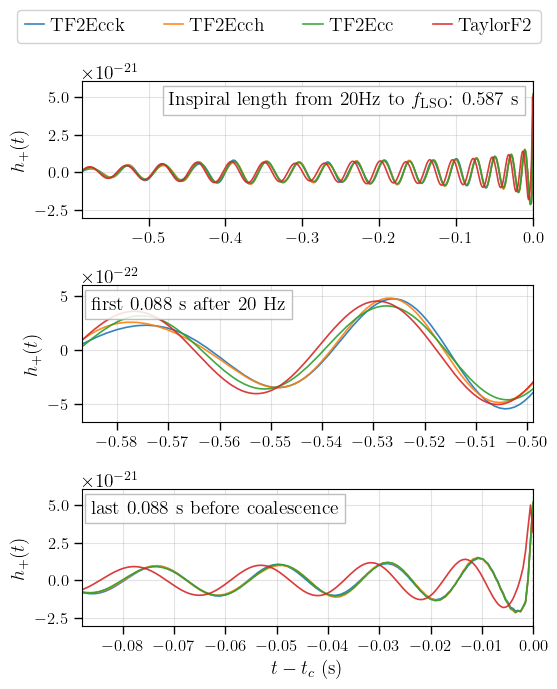

In [ ]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14
})

size_axis_label = 14
size_tick_label = 12
size_legend_label = 13

colors = {
    "TF2Ecck": "tab:blue",
    "TF2Ecch": "tab:orange",
    "TF2Ecc": "tab:green",
    "TaylorF2": "tab:red",
}

fig, (ax_full, ax_start, ax_coal) = plt.subplots(3, 1, figsize=(5.8, 7), facecolor="w")

for label, values in hplus_aligned.items():
    ax_full.plot(time, values, label=label, color=colors[label], lw=1.2, alpha=0.9)
    ax_start.plot(time, values, label=label, color=colors[label], lw=1.2, alpha=0.9)
    ax_coal.plot(time, values, label=label, color=colors[label], lw=1.2, alpha=0.9)

plot_start = -float(chirp_time)
plot_end = 0.0
zoom_width = min(0.2, 0.15 * float(chirp_time))
start_zoom = (plot_start, plot_start + zoom_width)
coal_zoom = (plot_end - zoom_width, plot_end)

windows = {
    ax_full: (plot_start, plot_end),
    ax_start: start_zoom,
    ax_coal: coal_zoom,
}

for ax, (xmin, xmax) in windows.items():
    ax.set_xlim(xmin, xmax)

# Give each panel an independent y-limit from the data visible in that panel.
def set_visible_ylim(ax, xmin, xmax, padding=0.12):
    mask = (time >= xmin) & (time <= xmax)
    visible = np.concatenate([values[mask] for values in hplus_aligned.values()])
    ymin, ymax = np.min(visible), np.max(visible)
    span = ymax - ymin
    if span == 0:
        span = max(abs(ymax), 1.0) * 0.1
    ax.set_ylim(ymin - padding * span, ymax + padding * span)

for ax, (xmin, xmax) in windows.items():
    set_visible_ylim(ax, xmin, xmax)

ax_full.set_ylabel(r"$h_+(t)$", fontsize=size_axis_label)
ax_start.set_ylabel(r"$h_+(t)$", fontsize=size_axis_label)
ax_coal.set_ylabel(r"$h_+(t)$", fontsize=size_axis_label)
ax_coal.set_xlabel(r"$t - t_c$ (s)", fontsize=size_axis_label)

ax_full.text(
    0.97, 0.92,
    r"Inspiral length from 20Hz to $f_{\rm LSO}$: "+f"{chirp_time:.3f} s",
    transform=ax_full.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.85),
)
ax_start.text(
    0.02, 0.92,
    f"first {zoom_width:.3f} s after {minimum_frequency:.0f} Hz",
    transform=ax_start.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.85),
)
ax_coal.text(
    0.02, 0.92,
    f"last {zoom_width:.3f} s before coalescence",
    transform=ax_coal.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.85),
)

for ax in (ax_full, ax_start, ax_coal):
    ax.tick_params(axis="both", which="both", labelsize=size_tick_label)
    ax.axvline(0.0, color="0.2", ls="--", lw=1.0, alpha=0.6)
    ax.grid(True, alpha=0.35)

handles, labels = ax_full.get_legend_handles_labels()
legend = fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=len(labels),
    handlelength=1.0,
    frameon=True,
    framealpha=0.9,
    fontsize=size_legend_label,
)
legend.get_frame().set_facecolor("white")

fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig("hplus_time_domain_comparison.pdf", bbox_inches="tight")
plt.show()
